In [5]:
# ============================================================================
# CELL 1: IMPORTS AND SETUP
# ============================================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


All libraries imported successfully!
PyTorch version: 2.8.0+cpu
CUDA available: False


In [6]:
# ============================================================================
# CELL 2: CONFIGURATION
# ============================================================================

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Paths
ASSIGNMENT_PATH = "/kaggle/input/assignment-3/Assignment 3"
TRAIN_DIR = f"{ASSIGNMENT_PATH}/train"
TEST_DIR = f"{ASSIGNMENT_PATH}/test"
CLASS_MAP_FILE = f"{ASSIGNMENT_PATH}/class_map.json"


# Hyperparameters - OPTIMIZED FOR FASTER TRAINING
IMG_SIZE = 224  # Reduced from 224 to 128 for faster processing
BATCH_SIZE = 64  # Increased batch size for efficiency
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
NUM_CLASSES = 8

# Load class mapping
with open(CLASS_MAP_FILE, 'r') as f:
    class_map = json.load(f)

print("\nClass Mapping:")
for cell_type, class_id in sorted(class_map.items(), key=lambda x: x[1]):
    print(f"  {class_id}: {cell_type}")

print(f"   - Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"   - Batch size: {BATCH_SIZE}")


Using device: cpu

Class Mapping:
  0: basophil
  1: eosinophil
  2: erythroblast
  3: ig
  4: lymphocyte
  5: monocyte
  6: neutrophil
  7: platelet
   - Image size: 224x224
   - Batch size: 64



DATA EXPLORATION

Class Distribution:
       Class  Count
    Basophil    400
  Eosinophil    400
Erythroblast    400
          IG    400
  Lymphocyte    400
    Monocyte    400
  Neutrophil    400
    Platelet    400


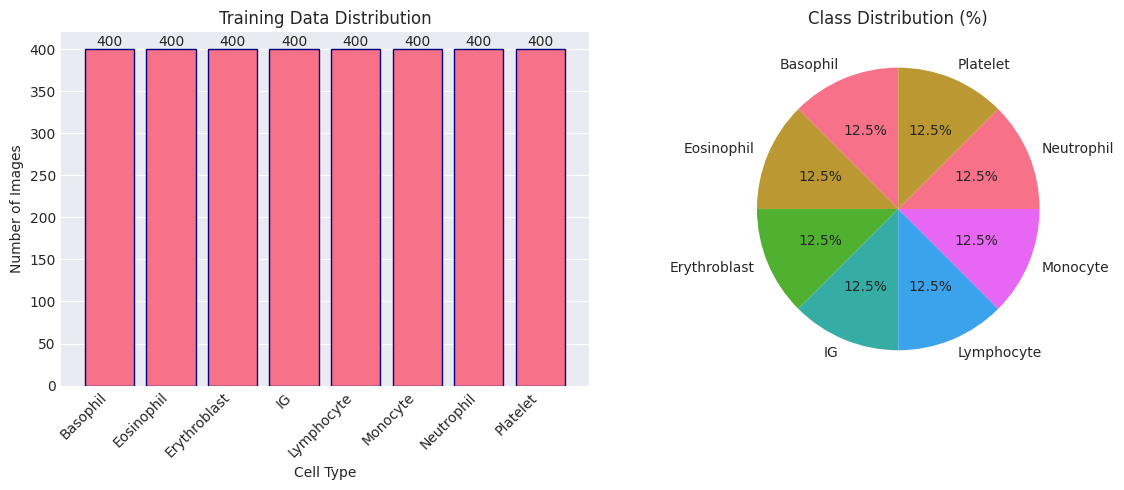


Total training images: 3200
Total test images: 1000


In [7]:
# ============================================================================
# CELL 3: DATA EXPLORATION
# ============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("DATA EXPLORATION")
print("="*60)

# Count training images by class using directory structure
def count_images_in_subdirs(train_dir):
    """Count images in each class subdirectory"""
    class_counts = {}
    class_dirs = ['basophil', 'eosinophil', 'erythroblast', 'ig', 
                  'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
    
    for i, class_dir in enumerate(class_dirs):
        dir_path = os.path.join(train_dir, class_dir)
        if os.path.exists(dir_path):
            jpg_files = [f for f in os.listdir(dir_path) if f.lower().endswith('.jpg')]
            class_counts[i] = len(jpg_files)
        else:
            class_counts[i] = 0
    
    return class_counts

# Get counts for each class
class_counts_dict = count_images_in_subdirs(TRAIN_DIR)
counts = np.array([class_counts_dict[i] for i in range(8)])

# Class names
class_names = ['Basophil', 'Eosinophil', 'Erythroblast', 'IG', 
               'Lymphocyte', 'Monocyte', 'Neutrophil', 'Platelet']

# Create DataFrame for visualization
df_dist = pd.DataFrame({'Class': class_names, 'Count': counts})

print("\nClass Distribution:")
print(df_dist.to_string(index=False))

# Check if we have any data
total_images = counts.sum()
if total_images == 0:
    print("\n⚠️  Warning: No training images found!")
    print("Please check if the train directory contains subdirectories with images.")
else:
    # Visualize distribution only if we have data
    plt.figure(figsize=(12, 5))

    # Bar Chart
    plt.subplot(1, 2, 1)
    bars = plt.bar(class_names, counts, edgecolor='navy')
    plt.xlabel('Cell Type')
    plt.ylabel('Number of Images')
    plt.title('Training Data Distribution')
    plt.xticks(rotation=45, ha='right')
    
    # Add value labels on bars
    for bar, count in zip(bars, counts):
        if count > 0:
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(count), ha='center', va='bottom')

    # Pie Chart - only create if we have non-zero data
    plt.subplot(1, 2, 2)
    if total_images > 0:
        # Filter out zero counts for pie chart
        non_zero_counts = counts[counts > 0]
        non_zero_names = [class_names[i] for i in range(len(counts)) if counts[i] > 0]
        
        if len(non_zero_counts) > 0:
            plt.pie(non_zero_counts, labels=non_zero_names, autopct='%1.1f%%', startangle=90)
            plt.title('Class Distribution (%)')
        else:
            plt.text(0.5, 0.5, 'No Data Available', ha='center', va='center', 
                    transform=plt.gca().transAxes, fontsize=14)
            plt.title('Class Distribution (%)')
    else:
        plt.text(0.5, 0.5, 'No Data Available', ha='center', va='center', 
                transform=plt.gca().transAxes, fontsize=14)
        plt.title('Class Distribution (%)')

    plt.tight_layout()
    
    # Save and show
    plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f"\nTotal training images: {total_images}")

# Count test images
test_images = 0
if os.path.exists(TEST_DIR):
    test_files = [f for f in os.listdir(TEST_DIR) if f.lower().endswith('.jpg')]
    test_images = len(test_files)

print(f"Total test images: {test_images}")

# Also create a function to get labels from directory structure for later use
def get_label_from_directory_structure(filepath, train_dir):
    """Extract class label from directory structure."""
    class_dirs = ['basophil', 'eosinophil', 'erythroblast', 'ig', 
                  'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
    
    # Get the parent directory name
    parent_dir = os.path.basename(os.path.dirname(filepath))
    
    try:
        return class_dirs.index(parent_dir)
    except ValueError:
        return -1  # Unknown class

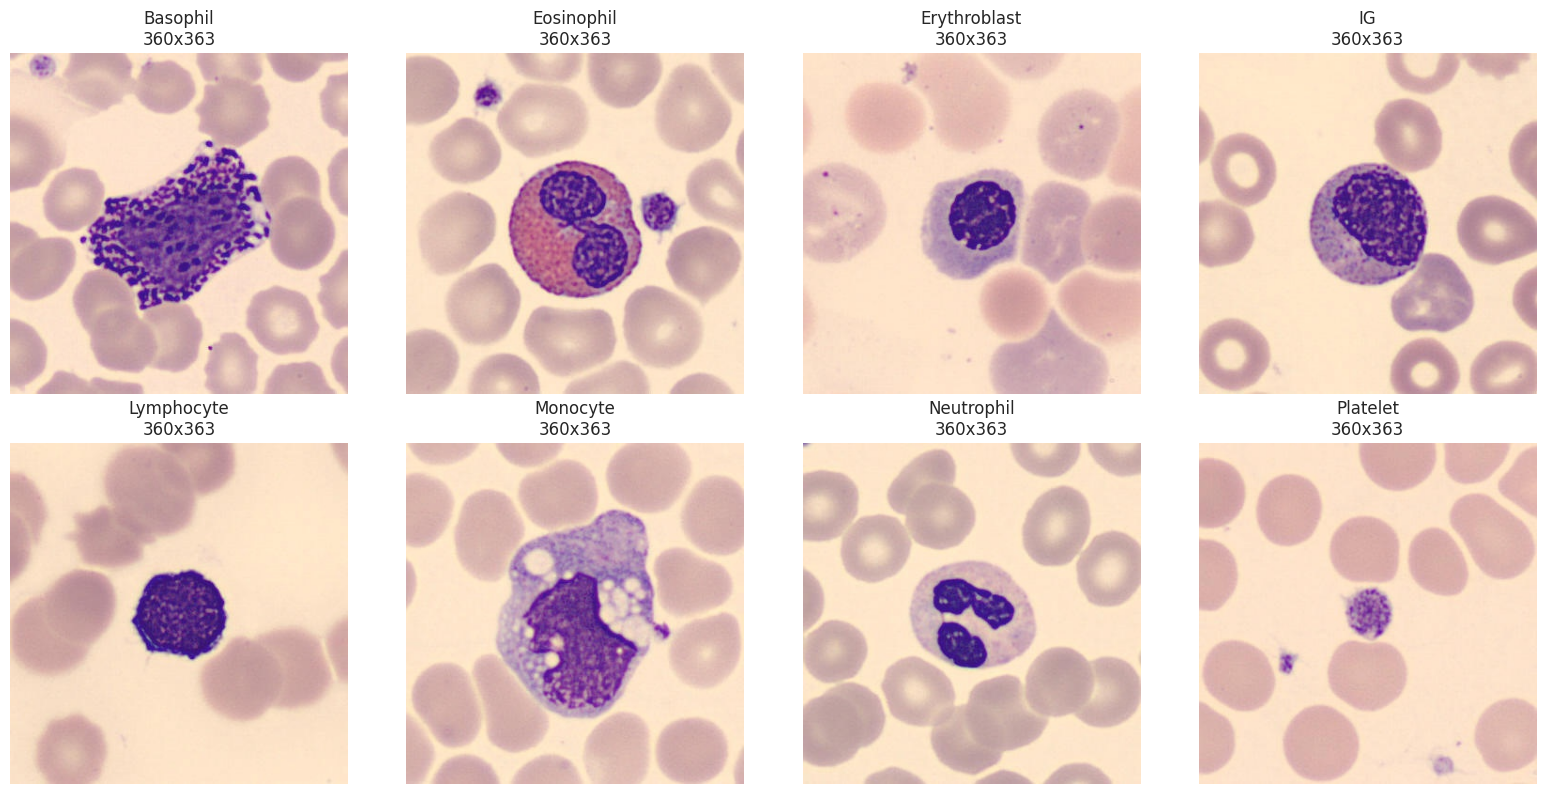

In [8]:
# ============================================================================
# CELL 4: VISUALIZE SAMPLE IMAGES
# ============================================================================

def visualize_samples(img_dir, num_per_class=1):
    """Visualize sample images from each class"""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    class_dirs = ['basophil', 'eosinophil', 'erythroblast', 'ig', 
                  'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
    
    for class_id, class_dir in enumerate(class_dirs):
        class_path = os.path.join(img_dir, class_dir)
        
        if os.path.exists(class_path):
            # Find first image of this class
            files = [f for f in os.listdir(class_path) if f.lower().endswith('.jpg')]
            
            if files:
                img_path = os.path.join(class_path, files[0])
                img = Image.open(img_path)
                
                axes[class_id].imshow(img)
                axes[class_id].set_title(f'{class_names[class_id]}\n{img.size[0]}x{img.size[1]}')
                axes[class_id].axis('off')
            else:
                # No image found for this class
                axes[class_id].text(0.5, 0.5, f'No {class_names[class_id]}\nImages Found', 
                                  ha='center', va='center', transform=axes[class_id].transAxes)
                axes[class_id].set_title(f'{class_names[class_id]}\nNo Images')
                axes[class_id].axis('off')
        else:
            # Directory doesn't exist
            axes[class_id].text(0.5, 0.5, f'{class_names[class_id]}\nDirectory Missing', 
                              ha='center', va='center', transform=axes[class_id].transAxes)
            axes[class_id].set_title(f'{class_names[class_id]}\nMissing')
            axes[class_id].axis('off')
    
    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_samples(TRAIN_DIR)

In [9]:
# ============================================================================
# CELL 5: DATASET CLASS
# ============================================================================

class BloodCellDataset(Dataset):
    """Custom Dataset for blood cell images"""
    
    def __init__(self, img_dir, transform=None, is_test=False, subset_size=None):
        """
        Args:
            img_dir: Directory containing images (either flat structure for test or subdirs for train)
            transform: Optional transforms to apply
            is_test: If True, don't extract labels and expect flat structure
            subset_size: If provided, limit number of images per class (for quick testing)
        """
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test
        
        # Get all image files
        if is_test:
            # Test directory has flat structure
            self.images = sorted([f for f in os.listdir(img_dir) if f.lower().endswith('.jpg')])
            self.image_paths = [os.path.join(img_dir, f) for f in self.images]
        else:
            # Training directory has subdirectory structure
            self.images = []
            self.image_paths = []
            self.labels = []
            
            class_dirs = ['basophil', 'eosinophil', 'erythroblast', 'ig', 
                         'lymphocyte', 'monocyte', 'neutrophil', 'platelet']
            
            for class_id, class_dir in enumerate(class_dirs):
                class_path = os.path.join(img_dir, class_dir)
                if os.path.exists(class_path):
                    class_images = sorted([f for f in os.listdir(class_path) 
                                         if f.lower().endswith('.jpg')])
                    
                    # Limit number of images per class if subset_size is specified
                    if subset_size is not None:
                        class_images = class_images[:subset_size]
                    
                    for img_name in class_images:
                        self.images.append(img_name)
                        self.image_paths.append(os.path.join(class_path, img_name))
                        self.labels.append(class_id)
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = self.image_paths[idx]
        
        # Load image
        image = Image.open(img_path).convert('RGB')
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        if self.is_test:
            return image, img_name
        else:
            label = self.labels[idx]
            return image, label

print("Dataset class defined successfully!")

Dataset class defined successfully!


In [10]:
# ============================================================================
# CELL 6: DATA TRANSFORMS AND LOADERS
# ============================================================================

# Data augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# No augmentation for validation/test
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_train_dataset = BloodCellDataset(TRAIN_DIR, transform=train_transform, is_test=False)
test_dataset = BloodCellDataset(TEST_DIR, transform=test_transform, is_test=True)

# Split training into train and validation (80/20)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Create data loaders with reduced num_workers for stability
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\nDataset sizes:")
print(f"  Training: {len(train_dataset)}")
print(f"  Validation: {len(val_dataset)}")
print(f"  Test: {len(test_dataset)}")
print(f"\nBatch size: {BATCH_SIZE}")
print(f"Number of batches - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")



Dataset sizes:
  Training: 2560
  Validation: 640
  Test: 1000

Batch size: 64
Number of batches - Train: 40, Val: 10, Test: 16


In [11]:
# ============================================================================
# CELL 7: BASELINE MODEL 1 - SIMPLE CNN
# ============================================================================

class SimpleCNN(nn.Module):
    """Baseline 1: Simple CNN with 3 convolutional blocks"""
    
    def __init__(self, num_classes=8, img_size=128):
        super(SimpleCNN, self).__init__()
        
        # Convolutional blocks
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # Calculate the size after conv layers
        # After 3 max pools (each /2): img_size -> img_size/8
        conv_output_size = (img_size // 8) * (img_size // 8) * 128
        
        # Fully connected layers
        self.fc1 = nn.Linear(conv_output_size, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
    
    def forward(self, x):
        # Conv blocks
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        
        x = F.relu(self.conv3(x))
        x = self.pool3(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # FC layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Test model with current image size
model_test = SimpleCNN(num_classes=NUM_CLASSES, img_size=IMG_SIZE)
print(f"SimpleCNN Total parameters: {sum(p.numel() for p in model_test.parameters()):,}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Expected tensor size after conv layers: {(IMG_SIZE//8) * (IMG_SIZE//8) * 128}")


SimpleCNN Total parameters: 51,478,088
Image size: 224x224
Expected tensor size after conv layers: 100352


In [12]:
# ============================================================================
# CELL 8: BASELINE MODEL 2 - IMPROVED CNN WITH BATCHNORM
# ============================================================================

class ImprovedCNN(nn.Module):
    """Baseline 2: CNN with BatchNorm and more layers"""
    
    def __init__(self, num_classes=8, img_size=128):
        super(ImprovedCNN, self).__init__()
        
        # Block 1
        self.conv1_1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1_1 = nn.BatchNorm2d(64)
        self.conv1_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn1_2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Block 2
        self.conv2_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2_1 = nn.BatchNorm2d(128)
        self.conv2_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn2_2 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Block 3
        self.conv3_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3_1 = nn.BatchNorm2d(256)
        self.conv3_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn3_2 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # Calculate the size after conv layers
        # After 3 max pools (each /2): img_size -> img_size/8
        conv_output_size = (img_size // 8) * (img_size // 8) * 256
        
        # Classifier
        self.fc1 = nn.Linear(conv_output_size, 1024)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(1024, 512)
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(512, num_classes)
    
    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1_1(self.conv1_1(x)))
        x = F.relu(self.bn1_2(self.conv1_2(x)))
        x = self.pool1(x)
        
        # Block 2
        x = F.relu(self.bn2_1(self.conv2_1(x)))
        x = F.relu(self.bn2_2(self.conv2_2(x)))
        x = self.pool2(x)
        
        # Block 3
        x = F.relu(self.bn3_1(self.conv3_1(x)))
        x = F.relu(self.bn3_2(self.conv3_2(x)))
        x = self.pool3(x)
        
        # Flatten and classify
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        
        return x

model_test2 = ImprovedCNN(num_classes=NUM_CLASSES, img_size=IMG_SIZE)
print(f"ImprovedCNN Total parameters: {sum(p.numel() for p in model_test2.parameters()):,}")


ImprovedCNN Total parameters: 207,198,024


In [13]:
# ============================================================================
# CELL 9: MAIN MODEL - CUSTOM RESNET
# ============================================================================

class ResidualBlock(nn.Module):
    """Residual block with skip connection"""
    
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        
        # Main path
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, 
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Skip connection
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                         stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class CustomResNet(nn.Module):
    """Main Model: ResNet-style architecture"""
    
    def __init__(self, num_classes=8):
        super(CustomResNet, self).__init__()
        
        # Initial convolution
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Residual layers
        self.layer1 = self._make_layer(64, 64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(64, 128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, num_blocks=2, stride=2)
        
        # Classifier
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)
    
    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride))
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels, 1))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        
        return x

model_test3 = CustomResNet(num_classes=NUM_CLASSES)
print(f"CustomResNet Total parameters: {sum(p.numel() for p in model_test3.parameters()):,}")



CustomResNet Total parameters: 11,180,616


In [14]:
# ============================================================================
# CELL 10: TRAINING AND EVALUATION FUNCTIONS
# ============================================================================

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in tqdm(train_loader, desc='Training', leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def validate(model, val_loader, criterion, device):
    """Validate model"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc='Validation', leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    val_loss = running_loss / len(val_loader)
    val_acc = 100. * correct / total
    return val_loss, val_acc


def train_model(model, train_loader, val_loader, criterion, optimizer, 
                num_epochs, device, scheduler=None, model_name='model'):
    """Complete training loop"""
    model = model.to(device)
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    best_val_acc = 0.0
    
    print(f"\nTraining {model_name}...")
    for epoch in range(num_epochs):
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validate
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        # Update scheduler
        if scheduler:
            scheduler.step()
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name}.pth')
            print(f'✓ New best model saved at epoch {epoch+1} with Val Acc: {val_acc:.2f}%')
        
        # Print progress every epoch (changed from every 5 epochs)
        if (epoch + 1) % 1 == 0:  # Changed from % 5 to % 1 to print every epoch
            print(f'Epoch [{epoch+1}/{num_epochs}] '
                  f'Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | '
                  f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%')
    
    print(f'Best Validation Accuracy: {best_val_acc:.2f}%')
    return history

print("Training functions defined successfully!")


Training functions defined successfully!


In [15]:
# ============================================================================
# CELL 11: EXPERIMENT 1 - BASELINE SIMPLE CNN
# ============================================================================

print("\n" + "="*70)
print("EXPERIMENT 1: SIMPLE CNN BASELINE")
print("="*70)

# Initialize model with correct image size
model1 = SimpleCNN(num_classes=NUM_CLASSES, img_size=IMG_SIZE)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(model1.parameters(), lr=LEARNING_RATE)

# Train model
history1 = train_model(
    model=model1,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer1,
    num_epochs=15,
    device=device,
    model_name='simple_cnn'
)


EXPERIMENT 1: SIMPLE CNN BASELINE

Training simple_cnn...


✓ New best model saved at epoch 1 with Val Acc: 43.28%
Epoch [1/15] Train Loss: 2.2288 Acc: 24.88% | Val Loss: 1.4506 Acc: 43.28%


✓ New best model saved at epoch 2 with Val Acc: 54.38%
Epoch [2/15] Train Loss: 1.4271 Acc: 44.18% | Val Loss: 1.2525 Acc: 54.38%


Epoch [3/15] Train Loss: 1.2663 Acc: 50.08% | Val Loss: 1.1829 Acc: 54.38%


✓ New best model saved at epoch 4 with Val Acc: 58.12%
Epoch [4/15] Train Loss: 1.2012 Acc: 54.73% | Val Loss: 1.1168 Acc: 58.12%


...

✓ New best model saved at epoch 11 with Val Acc: 77.03%
Epoch [11/15] Train Loss: 0.6859 Acc: 75.55% | Val Loss: 0.6369 Acc: 77.03%


✓ New best model saved at epoch 12 with Val Acc: 80.47%
Epoch [12/15] Train Loss: 0.6087 Acc: 78.48% | Val Loss: 0.5975 Acc: 80.47%


Epoch [13/15] Train Loss: 0.5732 Acc: 79.92% | Val Loss: 0.5804 Acc: 78.12%


✓ New best model saved at epoch 14 with Val Acc: 80.62%
Epoch [14/15] Train Loss: 0.5194 Acc: 81.84% | Val Loss: 0.5693 Acc: 80.62%


✓ New best model saved at epoch 15 with Val Acc: 81.09%
Epoch [15/15] Train Loss: 0.5012 Acc: 81.99% | Val Loss: 0.5141 Acc: 81.09%
Best Validation Accuracy: 81.09%


In [18]:
# ============================================================================
# CELL 12: EXPERIMENT 2 - MAIN MODEL (CUSTOM RESNET)
# ============================================================================

print("\n" + "="*70)
print("EXPERIMENT 2: CUSTOM RESNET (MAIN MODEL)")
print("="*70)

# Initialize model
model3 = CustomResNet(num_classes=NUM_CLASSES).to(device)

# Loss and optimizer with weight decay
criterion = nn.CrossEntropyLoss()
optimizer3 = optim.Adam(model3.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Learning rate scheduler
scheduler3 = optim.lr_scheduler.StepLR(optimizer3, step_size=20, gamma=0.1)

# Train model
history3 = train_model(
    model=model3,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer3,
    num_epochs=15,            # Explicitly set to 15 epochs
    device=device,
    scheduler=scheduler3,
    model_name='custom_resnet'
)



EXPERIMENT 2: CUSTOM RESNET (MAIN MODEL)

Training custom_resnet...


✓ New best model saved at epoch 1 with Val Acc: 20.16%
Epoch [1/15] Train Loss: 1.4739 Acc: 43.44% | Val Loss: 2.7757 Acc: 20.16%


✓ New best model saved at epoch 2 with Val Acc: 55.47%
Epoch [2/15] Train Loss: 0.9584 Acc: 62.73% | Val Loss: 1.0856 Acc: 55.47%


Epoch [3/15] Train Loss: 0.8463 Acc: 67.46% | Val Loss: 1.8047 Acc: 45.47%


Epoch [4/15] Train Loss: 0.7387 Acc: 72.54% | Val Loss: 1.2877 Acc: 54.53%


...

✓ New best model saved at epoch 11 with Val Acc: 73.91%
Epoch [11/15] Train Loss: 0.3952 Acc: 86.29% | Val Loss: 0.7180 Acc: 73.91%


Epoch [12/15] Train Loss: 0.3437 Acc: 87.38% | Val Loss: 1.6126 Acc: 51.88%


Epoch [13/15] Train Loss: 0.3339 Acc: 88.16% | Val Loss: 3.3337 Acc: 41.25%


Epoch [14/15] Train Loss: 0.3470 Acc: 87.54% | Val Loss: 1.0150 Acc: 71.09%


✓ New best model saved at epoch 15 with Val Acc: 78.91%
Epoch [15/15] Train Loss: 0.3127 Acc: 88.91% | Val Loss: 0.6265 Acc: 78.91%
Best Validation Accuracy: 78.91%


In [22]:
# ============================================================================
# CELL 13: ABLATION STUDY
# ============================================================================

print("\n" + "="*70)
print("ABLATION STUDY")
print("="*70)

ablation_results = {}

# 1. Test without data augmentation
print("\n1. Testing without data augmentation...")
no_aug_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Use full training dataset (subset_param removed)
no_aug_dataset = BloodCellDataset(TRAIN_DIR, transform=no_aug_transform, is_test=False)

# Calculate new split sizes for this dataset
no_aug_train_size = int(0.8 * len(no_aug_dataset))
no_aug_val_size = len(no_aug_dataset) - no_aug_train_size

no_aug_train, no_aug_val = random_split(no_aug_dataset, [no_aug_train_size, no_aug_val_size])
no_aug_train_loader = DataLoader(no_aug_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
no_aug_val_loader = DataLoader(no_aug_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model_no_aug = CustomResNet(num_classes=NUM_CLASSES).to(device)
optimizer_no_aug = optim.Adam(model_no_aug.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler_no_aug = optim.lr_scheduler.StepLR(optimizer_no_aug, step_size=20, gamma=0.1)

history_no_aug = train_model(
    model=model_no_aug,
    train_loader=no_aug_train_loader,
    val_loader=no_aug_val_loader,
    criterion=criterion,
    optimizer=optimizer_no_aug,
    num_epochs=10,  # Reduced for quick testing
    device=device,
    scheduler=scheduler_no_aug,
    model_name='no_augmentation'
)
ablation_results['No Augmentation'] = max(history_no_aug['val_acc'])

# 2. Test with higher learning rate
print("\n2. Testing with higher learning rate (0.01)...")
model_high_lr = CustomResNet(num_classes=NUM_CLASSES).to(device)
optimizer_high_lr = optim.Adam(model_high_lr.parameters(), lr=0.01, weight_decay=1e-4)

history_high_lr = train_model(
    model=model_high_lr,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_high_lr,
    num_epochs=10,
    device=device,
    model_name='high_lr'
)
ablation_results['High LR (0.01)'] = max(history_high_lr['val_acc'])

# 3. Test with SGD optimizer
print("\n3. Testing with SGD optimizer...")
model_sgd = CustomResNet(num_classes=NUM_CLASSES).to(device)
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=LEARNING_RATE, momentum=0.9, weight_decay=1e-4)

history_sgd = train_model(
    model=model_sgd,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_sgd,
    num_epochs=10,
    device=device,
    model_name='sgd_optimizer'
)
ablation_results['SGD Optimizer'] = max(history_sgd['val_acc'])

# 4. Test without weight decay
print("\n4. Testing without weight decay...")
model_no_wd = CustomResNet(num_classes=NUM_CLASSES).to(device)
optimizer_no_wd = optim.Adam(model_no_wd.parameters(), lr=LEARNING_RATE)

history_no_wd = train_model(
    model=model_no_wd,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_no_wd,
    num_epochs=10,
    device=device,
    model_name='no_weight_decay'
)
ablation_results['No Weight Decay'] = max(history_no_wd['val_acc'])

# Add main model result (if available)
if 'history3' in globals():
    ablation_results['Main Model (Full)'] = max(history3['val_acc'])
else:
    print("Note: Main model (history3) not available yet for comparison")

# Print ablation study results
print("\n" + "="*70)
print("ABLATION STUDY RESULTS")
print("="*70)
df_ablation = pd.DataFrame(list(ablation_results.items()), 
                           columns=['Configuration', 'Best Val Accuracy (%)'])
df_ablation = df_ablation.sort_values('Best Val Accuracy (%)', ascending=False)
print(df_ablation.to_string(index=False))



ABLATION STUDY

1. Testing without data augmentation...

Training no_augmentation...


✓ New best model saved at epoch 1 with Val Acc: 19.22%
Epoch [1/10] Train Loss: 0.9301 Acc: 67.38% | Val Loss: 14.1218 Acc: 19.22%


✓ New best model saved at epoch 2 with Val Acc: 25.16%
Epoch [2/10] Train Loss: 0.4667 Acc: 83.32% | Val Loss: 12.7709 Acc: 25.16%


✓ New best model saved at epoch 3 with Val Acc: 38.44%
Epoch [3/10] Train Loss: 0.3483 Acc: 87.70% | Val Loss: 3.6861 Acc: 38.44%


✓ New best model saved at epoch 4 with Val Acc: 69.84%
Epoch [4/10] Train Loss: 0.3025 Acc: 89.53% | Val Loss: 1.3080 Acc: 69.84%


...

Epoch [6/10] Train Loss: 0.5333 Acc: 82.23% | Val Loss: 1.1414 Acc: 65.47%


Epoch [7/10] Train Loss: 0.4964 Acc: 82.07% | Val Loss: 1.1425 Acc: 61.72%


Epoch [8/10] Train Loss: 0.4708 Acc: 82.42% | Val Loss: 1.2834 Acc: 63.44%


Epoch [9/10] Train Loss: 0.4395 Acc: 83.75% | Val Loss: 0.9183 Acc: 69.38%


Epoch [10/10] Train Loss: 0.3713 Acc: 86.45% | Val Loss: 1.5551 Acc: 60.78%
Best Validation Accuracy: 72.81%

ABLATION STUDY RESULTS
    Configuration  Best Val Accuracy (%)
Main Model (Full)               78.90625
  No Weight Decay               72.81250
    SGD Optimizer               71.25000
  No Augmentation               69.84375
   High LR (0.01)               57.03125


In [23]:
# ============================================================================
# CELL 14: COMPARISON OF ALL MODELS
# ============================================================================

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)

# Create comparison table
comparison_data = {
    'Model': ['Simple CNN', 'Custom ResNet'],
    'Parameters': [
        sum(p.numel() for p in SimpleCNN(img_size=IMG_SIZE).parameters()),
        sum(p.numel() for p in CustomResNet().parameters())
    ],
    'Best Train Acc (%)': [
        max(history1['train_acc']),
        max(history3['train_acc'])
    ],
    'Best Val Acc (%)': [
        max(history1['val_acc']),
        max(history3['val_acc'])
    ],
    'Final Train Loss': [
        history1['train_loss'][-1],
        history3['train_loss'][-1]
    ],
    'Final Val Loss': [
        history1['val_loss'][-1],
        history3['val_loss'][-1]
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print("\n", df_comparison.to_string(index=False))


MODEL COMPARISON

         Model  Parameters  Best Train Acc (%)  Best Val Acc (%)  Final Train Loss  Final Val Loss
   Simple CNN    51478088           81.992188          81.09375          0.501240        0.514133
Custom ResNet    11180616           88.906250          78.90625          0.312684        0.626513


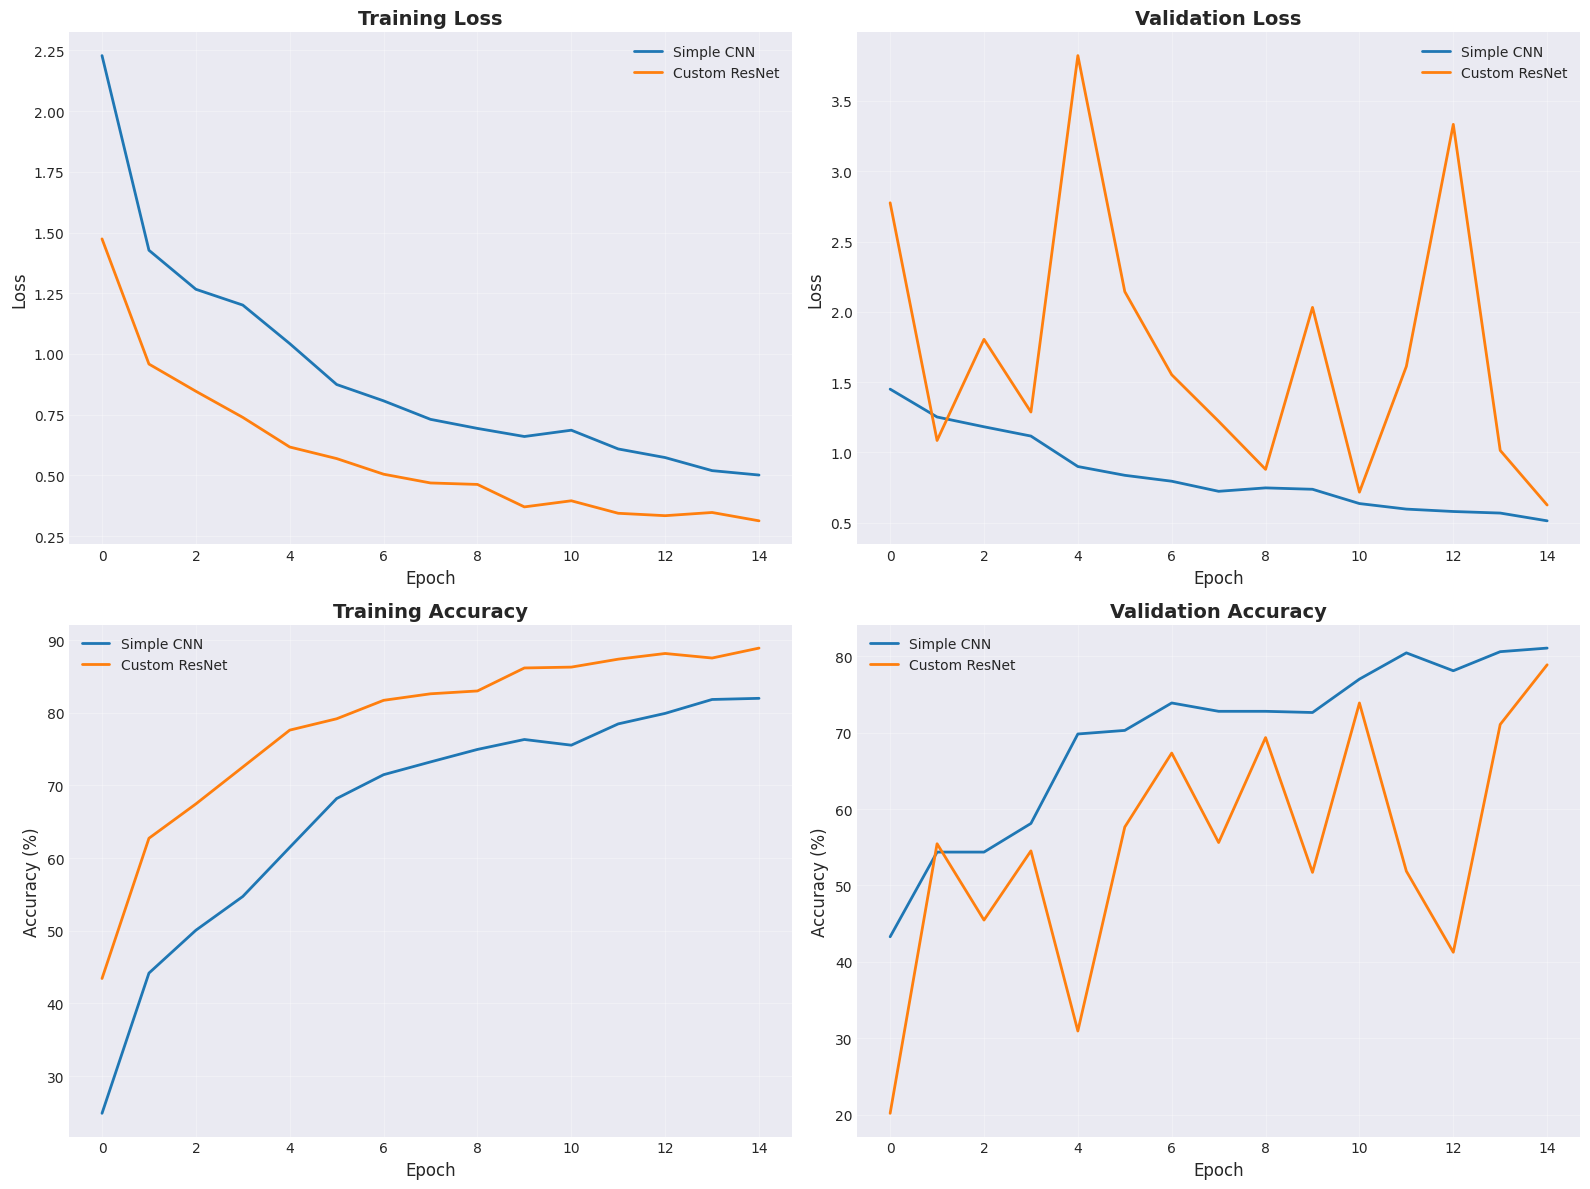

In [24]:
# ============================================================================
# CELL 15: VISUALIZE TRAINING CURVES
# ============================================================================

def plot_training_history(histories, names):
    """Plot training curves for multiple models"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    # Training Loss
    for i, (history, name) in enumerate(zip(histories, names)):
        axes[0, 0].plot(history['train_loss'], label=name, color=colors[i], linewidth=2)
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 0].set_title('Training Loss', fontsize=14, fontweight='bold')
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Validation Loss
    for i, (history, name) in enumerate(zip(histories, names)):
        axes[0, 1].plot(history['val_loss'], label=name, color=colors[i], linewidth=2)
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('Loss', fontsize=12)
    axes[0, 1].set_title('Validation Loss', fontsize=14, fontweight='bold')
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Training Accuracy
    for i, (history, name) in enumerate(zip(histories, names)):
        axes[1, 0].plot(history['train_acc'], label=name, color=colors[i], linewidth=2)
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1, 0].set_title('Training Accuracy', fontsize=14, fontweight='bold')
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Validation Accuracy
    for i, (history, name) in enumerate(zip(histories, names)):
        axes[1, 1].plot(history['val_acc'], label=name, color=colors[i], linewidth=2)
    axes[1, 1].set_xlabel('Epoch', fontsize=12)
    axes[1, 1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1, 1].set_title('Validation Accuracy', fontsize=14, fontweight='bold')
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

# Plot all models
plot_training_history(
    [history1, history3],
    ['Simple CNN', 'Custom ResNet']
)



In [25]:
# ============================================================================
# CELL 16: DETAILED EVALUATION ON VALIDATION SET
# ============================================================================

def evaluate_detailed(model, data_loader, device, model_name):
    """Evaluate model and generate confusion matrix"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(data_loader, desc=f'Evaluating {model_name}'):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # Classification report
    report = classification_report(all_labels, all_preds, 
                                   target_names=class_names, 
                                   digits=3)
    
    return accuracy, cm, report

# Load best models and evaluate
print("\n" + "="*70)
print("DETAILED EVALUATION ON VALIDATION SET")
print("="*70)

# Evaluate Simple CNN
model1.load_state_dict(torch.load('best_simple_cnn.pth'))
model1 = model1.to(device)
acc1, cm1, report1 = evaluate_detailed(model1, val_loader, device, 'Simple CNN')

print("\n--- Simple CNN ---")
print(f"Accuracy: {acc1*100:.2f}%")
print("\nClassification Report:")
print(report1)


# Evaluate Custom ResNet
model3.load_state_dict(torch.load('best_custom_resnet.pth'))
model3 = model3.to(device)
acc3, cm3, report3 = evaluate_detailed(model3, val_loader, device, 'Custom ResNet')

print("\n--- Custom ResNet ---")
print(f"Accuracy: {acc3*100:.2f}%")
print("\nClassification Report:")
print(report3)




DETAILED EVALUATION ON VALIDATION SET


Evaluating Simple CNN: 100%|██████████| 10/10 [00:07<00:00,  1.25it/s]



--- Simple CNN ---
Accuracy: 81.09%

Classification Report:
              precision    recall  f1-score   support

    Basophil      0.802     0.896     0.847        77
  Eosinophil      0.937     0.925     0.931        80
Erythroblast      0.864     0.714     0.782        98
          IG      0.580     0.607     0.593        84
  Lymphocyte      0.807     0.742     0.773        62
    Monocyte      0.713     0.805     0.756        77
  Neutrophil      0.825     0.846     0.835        78
    Platelet      0.988     0.964     0.976        84

    accuracy                          0.811       640
   macro avg      0.814     0.813     0.812       640
weighted avg      0.816     0.811     0.812       640



Evaluating Custom ResNet: 100%|██████████| 10/10 [00:05<00:00,  1.67it/s]


--- Custom ResNet ---
Accuracy: 79.22%

Classification Report:
              precision    recall  f1-score   support

    Basophil      1.000     0.260     0.412        77
  Eosinophil      0.986     0.900     0.941        80
Erythroblast      0.821     0.939     0.876        98
          IG      0.459     0.929     0.614        84
  Lymphocyte      0.935     0.694     0.796        62
    Monocyte      0.875     0.636     0.737        77
  Neutrophil      0.899     0.910     0.904        78
    Platelet      0.976     0.976     0.976        84

    accuracy                          0.792       640
   macro avg      0.869     0.780     0.782       640
weighted avg      0.863     0.792     0.786       640



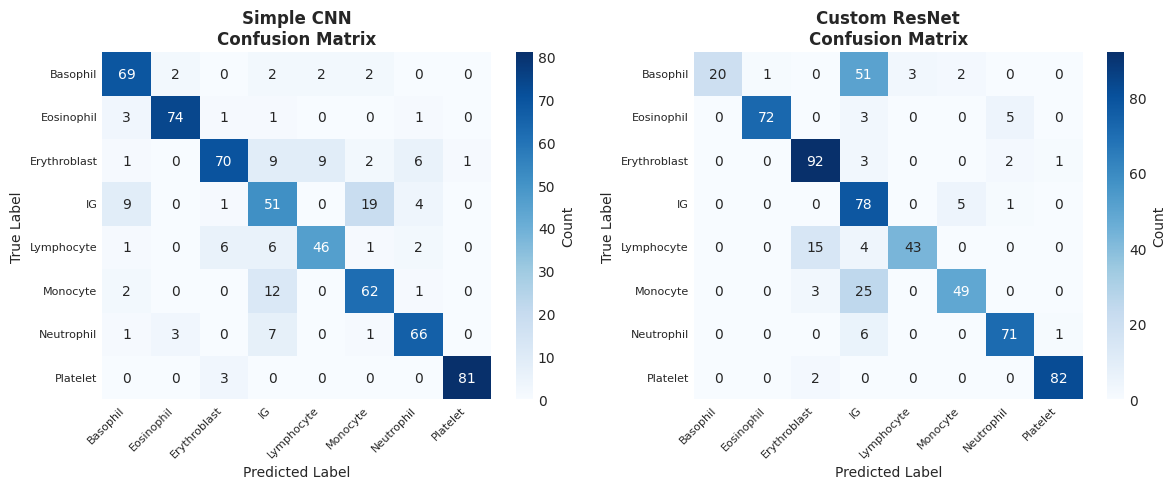

In [28]:
# ============================================================================
# CELL 17: PLOT CONFUSION MATRICES
# ============================================================================

def plot_confusion_matrices(cms, names, class_names):
    """Plot confusion matrices for all models"""
    n = len(cms)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    
    if n == 1:
        axes = [axes]  # Make it iterable
    
    for ax, cm, name in zip(axes, cms, names):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=class_names, yticklabels=class_names,
                   ax=ax, cbar_kws={'label': 'Count'})
        ax.set_title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold')
        ax.set_xlabel('Predicted Label', fontsize=10)
        ax.set_ylabel('True Label', fontsize=10)
        ax.tick_params(axis='both', labelsize=8)
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
    plt.show()

# Example usage
plot_confusion_matrices([cm1, cm3], ['Simple CNN', 'Custom ResNet'],  class_names)


In [33]:
# ============================================================================
# CELL 18: GENERATE TEST PREDICTIONS
# ============================================================================

print("\n" + "="*70)
print("GENERATING TEST PREDICTIONS")
print("="*70)

def generate_predictions(model, test_loader, device):
    """Generate predictions for test set"""
    model.eval()
    predictions = {}
    
    with torch.no_grad():
        for images, filenames in tqdm(test_loader, desc='Generating predictions'):
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            
            for filename, pred in zip(filenames, preds.cpu().numpy()):
                predictions[filename] = int(pred)
    
    return predictions

# Load best Custom ResNet model
model3.load_state_dict(torch.load('best_custom_resnet.pth'))
model3 = model3.to(device)
model3.eval()

# Generate predictions
predictions = generate_predictions(model3, test_loader, device)

# Save predictions to JSON
with open('prediction_labels.json', 'w') as f:
    json.dump(predictions, f, indent=4)

print(f"\n✓ Predictions saved to 'prediction_labels.json'")
print(f"✓ Total predictions: {len(predictions)}")



GENERATING TEST PREDICTIONS


Generating predictions: 100%|██████████| 16/16 [00:06<00:00,  2.50it/s]


✓ Predictions saved to 'prediction_labels.json'
✓ Total predictions: 1000
